# Cross Pulse Shape Comparison (Single charge_gate & prepared_state)
Load `outlier_results.h5` from different pulse shapes and compare outlier statistics
as a function of `amp_prefactor`. This notebook is for datasets where `prepared_state`
and `charge_gate` each have only one value.

In [2]:
import os
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
from scqat.parsers.xarray_h5_parser import load_xarray_h5

## 1. Configuration

In [82]:
output_folder = r"D:\SynologyDrive\LiChiehHsiao\AS\SynologyDrive\data\MIST\20260402\Q1\ng01_ref0165_test04\LZspeed_15"
# output_folder = r"D:\SynologyDrive\LiChiehHsiao\AS\SynologyDrive\data\MIST\20260402\Q1\ng01_ref0165_test04\LZspeed_20"

SHAPE_FOLDERS = {
    # "100": os.path.join(output_folder, "100"),
    # "200": os.path.join(output_folder, "200"),
    # "400": os.path.join(output_folder, "400"),
    # "800": os.path.join(output_folder, "800"),
    "square": os.path.join(output_folder, "square"),
}

FIGURE_SAVE_PATH = os.path.join(output_folder, "figures")
os.makedirs(FIGURE_SAVE_PATH, exist_ok=True)

# Normalization factor for amp_prefactor per shape
AMP_PREFACTOR_NORM = {k: 1.0 for k in SHAPE_FOLDERS}

# Consistent color per pulse shape
shape_colors = {label: f'C{i}' for i, label in enumerate(SHAPE_FOLDERS)}

## 2. Load datasets & squeeze single-valued coords

In [83]:
datasets = {}
ps_datasets = {}
for label, folder in SHAPE_FOLDERS.items():
    ds = load_xarray_h5(os.path.join(folder, "outlier_results.h5"))
    ds = ds.assign_coords(
        amp_prefactor=ds.amp_prefactor * AMP_PREFACTOR_NORM[label]
    )
    # Squeeze single-valued prepared_state and charge_gate
    # if 'prepared_state' in ds.dims and ds.sizes['prepared_state'] == 1:
    #     ds = ds.squeeze('prepared_state')
    if 'charge_gate' in ds.dims and ds.sizes['charge_gate'] == 1:
        ds = ds.squeeze('charge_gate')
    datasets[label] = ds

    ps_path = os.path.join(folder, "ro_charge_power_post_selected.h5")
    ps = load_xarray_h5(ps_path)
    ps = ps.assign_coords(
        amp_prefactor=ps.coords['amp_prefactor'] * AMP_PREFACTOR_NORM[label]
    )
    if 'charge_gate' in ps.dims and ps.sizes['charge_gate'] == 1:
        ps = ps.squeeze('charge_gate')
    ps_datasets[label] = ps
    print(f"[{label}] shot_idx size: {ps.sizes['shot_idx']}")

# Show one dataset for reference
sample = next(iter(datasets.values()))
print(sample)

[square] shot_idx size: 1000
<xarray.Dataset> Size: 2kB
Dimensions:                   (prepared_state: 1, amp_prefactor: 21)
Coordinates:
  * prepared_state            (prepared_state) int32 4B 0
    charge_gate               float64 8B 0.15
  * amp_prefactor             (amp_prefactor) float64 168B 0.8 0.825 ... 1.3
Data variables:
    outlier_probability_set3  (prepared_state, amp_prefactor) float64 168B 0....
    I_mean_set3               (prepared_state, amp_prefactor) float64 168B -0...
    Q_mean_set3               (prepared_state, amp_prefactor) float64 168B -0...
    std_set3                  (prepared_state, amp_prefactor) float64 168B 0....
    outlier_probability_set2  (prepared_state, amp_prefactor) float64 168B 0....
    I_mean_set2               (prepared_state, amp_prefactor) float64 168B -0...
    Q_mean_set2               (prepared_state, amp_prefactor) float64 168B -0...
    std_set2                  (prepared_state, amp_prefactor) float64 168B 0....
Attributes:
    a

## 4. Outlier Probability vs amp_prefactor (set2 & set3)

Saved cross_shape_outlier_prob_vs_amp_state0.png


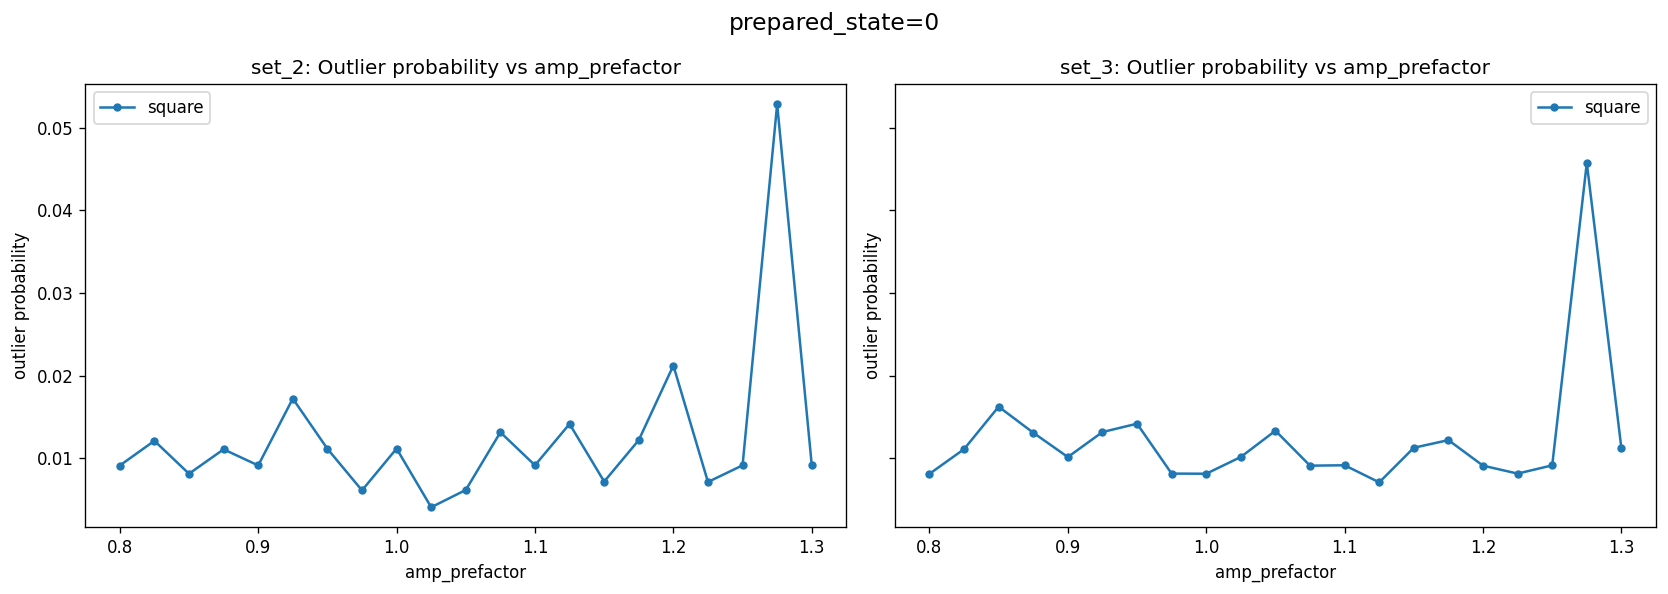

In [84]:
# Collect all prepared_state values across shapes
all_states = set()
for ds in datasets.values():
    if 'prepared_state' in ds.dims:
        all_states.update(ds.coords['prepared_state'].values.tolist())
all_states = sorted(all_states) if all_states else [None]

for state in all_states:
    fig, (ax_set2, ax_set3) = plt.subplots(1, 2, figsize=(14, 5), dpi=120, sharey=True)

    for label, ds in datasets.items():
        color = shape_colors[label]
        if state is not None and 'prepared_state' in ds.dims:
            if state not in ds.coords['prepared_state'].values:
                continue
            ds_sel = ds.sel(prepared_state=state)
        elif state is not None:
            # No prepared_state dim — plot as-is (pad)
            ds_sel = ds
        else:
            ds_sel = ds

        for var_name, set_label, ax in [('outlier_probability_set2', 'set_2', ax_set2),
                                         ('outlier_probability_set3', 'set_3', ax_set3)]:
            data = ds_sel[var_name]
            ax.plot(data.coords['amp_prefactor'].values, data.values,
                    marker='o', markersize=4, linestyle='-',
                    color=color, label=label)

    for ax, set_label in [(ax_set2, 'set_2'), (ax_set3, 'set_3')]:
        ax.set_xlabel('amp_prefactor')
        ax.set_ylabel('outlier probability')
        ax.set_title(f'{set_label}: Outlier probability vs amp_prefactor')
        ax.legend()

    state_str = f"prepared_state={int(state)}" if state is not None else ""
    fig.suptitle(state_str, fontsize=14)
    fig.tight_layout()

    suffix = f"_state{int(state)}" if state is not None else ""
    fname = f"cross_shape_outlier_prob_vs_amp{suffix}.png"
    fig.savefig(os.path.join(FIGURE_SAVE_PATH, fname), bbox_inches='tight')
    print(f"Saved {fname}")
    plt.show()

Saved cross_shape_std_vs_amp_state0.png


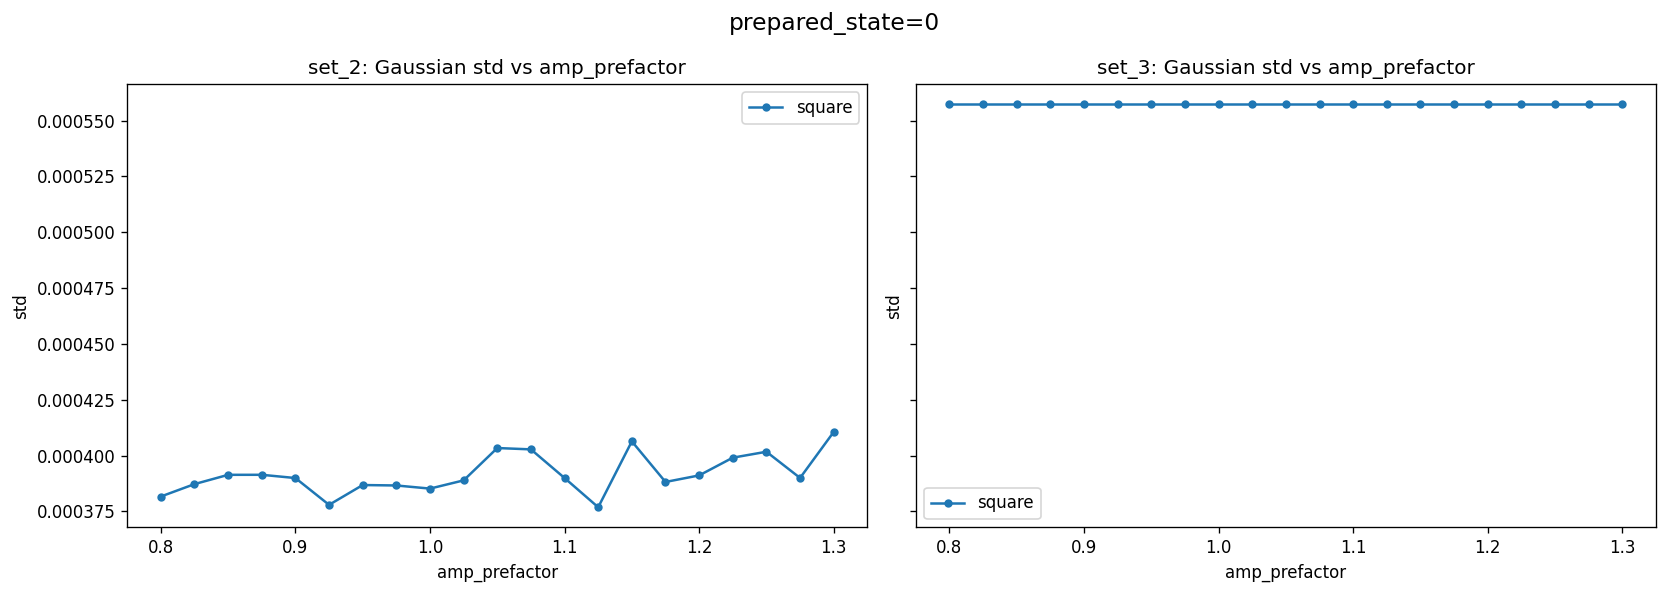

In [85]:
for state in all_states:
    fig, (ax_set2, ax_set3) = plt.subplots(1, 2, figsize=(14, 5), dpi=120, sharey=True)

    for label, ds in datasets.items():
        color = shape_colors[label]
        if state is not None and 'prepared_state' in ds.dims:
            if state not in ds.coords['prepared_state'].values:
                continue
            ds_sel = ds.sel(prepared_state=state)
        else:
            ds_sel = ds

        for var_name, set_label, ax in [('std_set2', 'set_2', ax_set2),
                                         ('std_set3', 'set_3', ax_set3)]:
            data = ds_sel[var_name]
            ax.plot(data.coords['amp_prefactor'].values, data.values,
                    marker='o', markersize=4, linestyle='-',
                    color=color, label=label)

    for ax, set_label in [(ax_set2, 'set_2'), (ax_set3, 'set_3')]:
        ax.set_xlabel('amp_prefactor')
        ax.set_ylabel('std')
        ax.set_title(f'{set_label}: Gaussian std vs amp_prefactor')
        ax.legend()

    state_str = f"prepared_state={int(state)}" if state is not None else ""
    fig.suptitle(state_str, fontsize=14)
    fig.tight_layout()

    suffix = f"_state{int(state)}" if state is not None else ""
    fname = f"cross_shape_std_vs_amp{suffix}.png"
    fig.savefig(os.path.join(FIGURE_SAVE_PATH, fname), bbox_inches='tight')
    print(f"Saved {fname}")
    plt.show()

Saved cross_shape_IQ_trajectory_vs_amp_state0.png


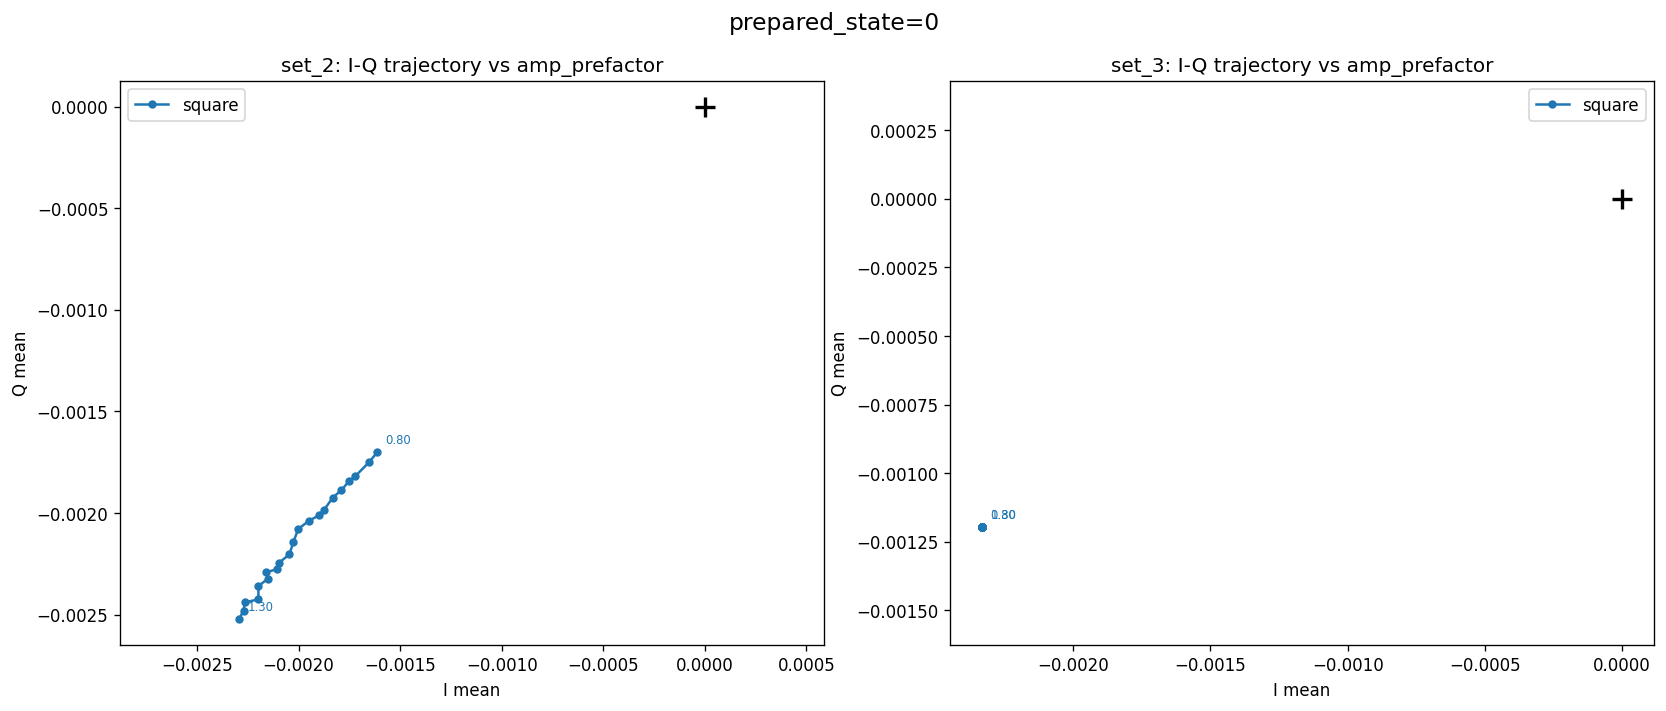

In [86]:
for state in all_states:
    fig, (ax_set2, ax_set3) = plt.subplots(1, 2, figsize=(14, 6), dpi=120)

    for label, ds in datasets.items():
        color = shape_colors[label]
        if state is not None and 'prepared_state' in ds.dims:
            if state not in ds.coords['prepared_state'].values:
                continue
            ds_sel = ds.sel(prepared_state=state)
        else:
            ds_sel = ds

        for i_var, q_var, set_label, ax in [
            ('I_mean_set2', 'Q_mean_set2', 'set_2', ax_set2),
            ('I_mean_set3', 'Q_mean_set3', 'set_3', ax_set3),
        ]:
            I_vals = ds_sel[i_var].values
            Q_vals = ds_sel[q_var].values
            amps = ds_sel.coords['amp_prefactor'].values
            ax.plot(I_vals, Q_vals, marker='o', markersize=4, linestyle='-',
                    color=color, label=label)
            # Annotate first and last amp_prefactor
            for idx in [0, -1]:
                ax.annotate(f'{amps[idx]:.2f}', (I_vals[idx], Q_vals[idx]),
                            textcoords='offset points', xytext=(5, 5),
                            fontsize=7, color=color)

    for ax, set_label in [(ax_set2, 'set_2'), (ax_set3, 'set_3')]:
        ax.plot(0, 0, 'k+', markersize=12, markeredgewidth=2, zorder=5)
        ax.set_xlabel('I mean')
        ax.set_ylabel('Q mean')
        ax.set_title(f'{set_label}: I-Q trajectory vs amp_prefactor')
        ax.legend()
        ax.set_aspect('equal', adjustable='datalim')

    state_str = f"prepared_state={int(state)}" if state is not None else ""
    fig.suptitle(state_str, fontsize=14)
    fig.tight_layout()

    suffix = f"_state{int(state)}" if state is not None else ""
    fname = f"cross_shape_IQ_trajectory_vs_amp{suffix}.png"
    fig.savefig(os.path.join(FIGURE_SAVE_PATH, fname), bbox_inches='tight')
    print(f"Saved {fname}")
    plt.show()

## 5. Single Grid-Point I/Q Scatter
Select a target `amp_prefactor` value. For each pulse shape, load per-shot data from
`ro_charge_power_post_selected.h5`, plot I/Q scatter (3 channel pairs) with outlier mask,
and overlay Gaussian center + 3σ circles from `outlier_results.h5`.

In [87]:
SELECTED_AMP = 1.05  # target amp_prefactor value (nearest match)

Saved cross_scatter_IQ_square_amp1.0500_state0.png


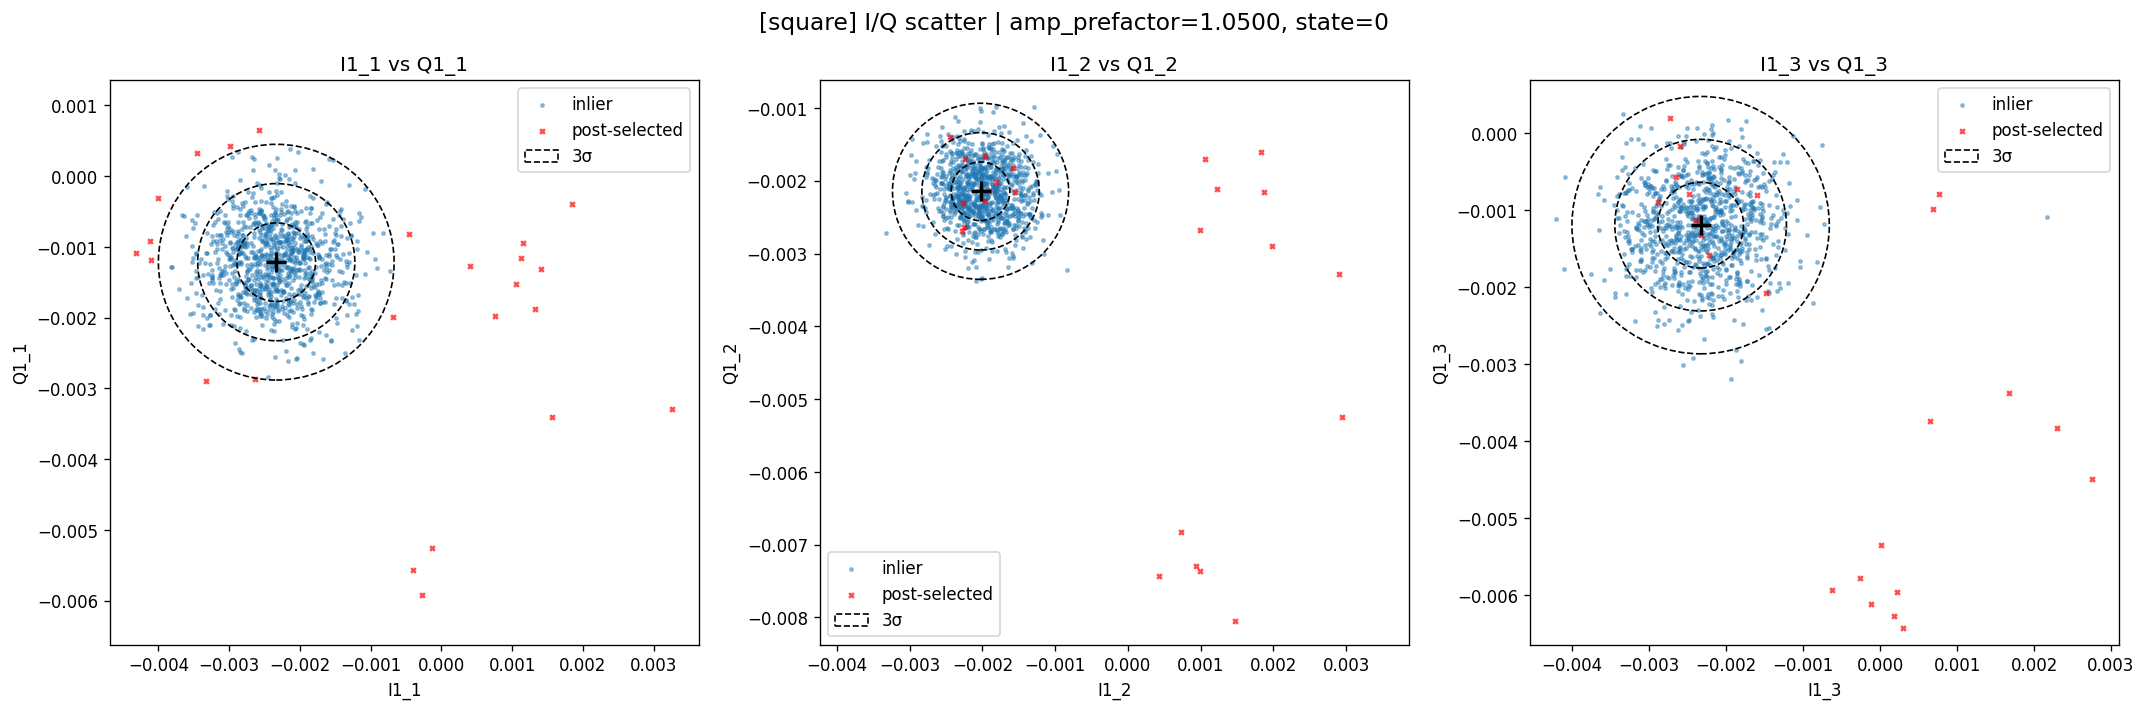

In [88]:
from matplotlib.patches import Circle

channel_pairs = [('I1_1', 'Q1_1'), ('I1_2', 'Q1_2'), ('I1_3', 'Q1_3')]
outlier_sigma = 3  # must match the sigma used during outlier analysis

for label in SHAPE_FOLDERS:
    ps_data = ps_datasets[label]

    # Determine prepared_states to iterate
    if 'prepared_state' in ps_data.dims:
        ps_states = ps_data.coords['prepared_state'].values.tolist()
    else:
        ps_states = [None]

    for state in ps_states:
        if state is not None:
            cell = ps_data.sel(prepared_state=state, amp_prefactor=SELECTED_AMP, method='nearest')
        else:
            cell = ps_data.sel(amp_prefactor=SELECTED_AMP, method='nearest')
        actual_amp = float(cell.coords['amp_prefactor'])
        mask = cell['outlier_mask'].values.astype(bool)

        # Get outlier_results stats at the same amp_prefactor
        ds_out = datasets[label]
        if state is not None and 'prepared_state' in ds_out.dims:
            out_cell = ds_out.sel(prepared_state=state, amp_prefactor=actual_amp, method='nearest')
        else:
            out_cell = ds_out.sel(amp_prefactor=actual_amp, method='nearest')

        # Reference (set1) center & std from dataset attrs
        ref_mean = np.atleast_1d(ps_data.attrs.get('mean', [np.nan, np.nan]))
        ref_std = float(ps_data.attrs.get('std', np.nan))

        # Per-channel Gaussian center & std: (ref/_2/_3)
        centers_stds = [
            (ref_mean[0], ref_mean[1], ref_std),
            (float(out_cell['I_mean_set2']), float(out_cell['Q_mean_set2']), float(out_cell['std_set2'])),
            (float(out_cell['I_mean_set3']), float(out_cell['Q_mean_set3']), float(out_cell['std_set3'])),
        ]

        # --- I/Q scatter plot (3 channel pairs) with circles ---
        fig, axes = plt.subplots(1, 3, figsize=(18, 6), dpi=120)
        for ax, (i_var, q_var), (cx, cy, std) in zip(axes, channel_pairs, centers_stds):
            I_vals = cell[i_var].values
            Q_vals = cell[q_var].values
            ax.scatter(I_vals[~mask], Q_vals[~mask], s=4, alpha=0.4, label='inlier', color='C0')
            ax.scatter(I_vals[mask], Q_vals[mask], s=8, alpha=0.7, label='post-selected', color='red', marker='x')
            # Draw center marker and nσ circles
            if not np.isnan(cx):
                ax.plot(cx, cy, '+', color='k', markersize=12, markeredgewidth=2)
                for n in range(1, outlier_sigma + 1):
                    circle = Circle((cx, cy), n * std, fill=False,
                                    edgecolor='k', linestyle='--', linewidth=1,
                                    label=f'{n}σ' if n == outlier_sigma else None)
                    ax.add_patch(circle)
            ax.set_xlabel(i_var)
            ax.set_ylabel(q_var)
            ax.set_title(f"{i_var} vs {q_var}")
            ax.legend()
            ax.set_aspect('equal', adjustable='datalim')

        state_str = f", state={int(state)}" if state is not None else ""
        fig.suptitle(f"[{label}] I/Q scatter | amp_prefactor={actual_amp:.4f}{state_str}", fontsize=14)
        fig.tight_layout()
        suffix = f"_state{int(state)}" if state is not None else ""
        fname = f"cross_scatter_IQ_{label}_amp{actual_amp:.4f}{suffix}.png"
        fig.savefig(os.path.join(FIGURE_SAVE_PATH, fname), bbox_inches='tight')
        print(f"Saved {fname}")
        plt.show()